In [1]:
import os
import random
import magnum as mn
import numpy as np
from PIL import Image
from matplotlib import pyplot as plt
from scipy.spatial.transform import Rotation as R
from ultralytics import YOLO 
from mylib import myutils
from mylib import simsettings
from mylib import simtools
from dotenv import load_dotenv
load_dotenv()

import habitat_sim
import habitat_sim.nav as nav
from habitat.utils.visualizations import maps
from habitat_sim.utils import common as utils
from habitat_sim.utils import viz_utils as vut
from habitat_sim.utils.common import quat_from_angle_axis, quat_to_angle_axis
from habitat_sim.utils.common import d3_40_colors_rgb

# Load YOLO model
yolo_model = YOLO("yolov8n.pt")  # Swap with yolov8s.pt or yolov8x.pt as needed

# Robotic agent propertis
AGENT_RADIUS = 0.15 # 15 cm
AGENT_HEIGHT = 1.5 # 150 cm

# Target object properties
TARGET_OBJECT = 'tv'

# Simulator configuration
dataset_config_file = os.path.join(os.getenv("AI2THOR_DATA"), "ai2thor-hab.scene_dataset_config.json")
scene = "FloorPlan215_physics"
sim_settings = {
    "seed": 1,
    "dataset": dataset_config_file,  # Scene dataset
    "scene": scene,  # Scene path
    "width": 1024,  # Spatial resolution of the observations
    "height": int(1024*9/16),
    "default_agent": 0,
    "sensor_height": AGENT_HEIGHT,  # Height of sensors in meters
    "color_sensor": True,  # RGB sensor
    "depth_sensor": True,  # Depth sensor
    "enable_physics": False,  # kinematics only
}
# Initialize the simulator
cfg = simsettings.make_cfg(sim_settings)
sim = habitat_sim.Simulator(cfg)

PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring


Renderer: NVIDIA GeForce GTX 1060 6GB/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 570.124.06
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-size-in-bits


PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring
[15:44:31:790414]:[Warning]:[Metadata] SceneDatasetAttributes.cpp(107)::addNewSceneInstanceToDataset : Dataset : 'ai2thor-hab' : Lighting Layout Attributes '/home/joaocbranco/projects/habitat-meta/ai2thor-hab/ai2thor-hab/configs/scenes/iTHOR/FloorPlan215_physics.scene_instance.json' specified in Scene Attributes but does not exist in dataset, so creating default.
MeshTools::compile(): ignoring Trade::MeshAttribute::TextureCoordinates 1 as its binding slot is already occupied by Trade::MeshAttribute::TextureCoordinates 0
MeshTools::compile(): ignoring Tr

In [2]:
# Get the root node of the active scene graph
scene_root = sim.get_active_scene_graph().get_root_node()
scene_bb = scene_root.cumulative_bb
scene_dims = scene_bb.size()

# Define navmesh settings
navmesh_settings = habitat_sim.NavMeshSettings()
navmesh_settings.agent_height = AGENT_HEIGHT
navmesh_settings.agent_radius = AGENT_RADIUS
navmesh_settings.agent_max_climb = 0.2
navmesh_settings.agent_max_slope = 45.0
navmesh_settings.include_static_objects = True  # Include static objects in the navmesh computation

# Recompute the navmesh for the current scene
sim.recompute_navmesh(sim.pathfinder, navmesh_settings)

# Generate the top-down map --> 1 cm per pixel
topdown_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=0.01, draw_border=True)
topdown_map = myutils.map_to_rgb(topdown_map)
topdown_map = myutils.add_axis_to_map(topdown_map)
topdown_resolution = topdown_map.shape[:2]

# Generate the coarse map --> 30 cm per pixel (robot has radius 15 cm)
occ_grid_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=0.30, draw_border=False)
occ_grid_map = myutils.map_to_rgb(occ_grid_map)
occ_grid_resolution = occ_grid_map.shape[:2]

# Occupiable positions
grid_occ_positions = []
real_wrld_positions = []
map_occ_positions = []
for x_g in range(occ_grid_resolution[0]):
    for y_g in range(occ_grid_resolution[1]):
        if occ_grid_map[x_g, y_g, 0] == 255: # White pixel
            # Convert to real world position
            real_wrld_z, real_wrld_x = maps.from_grid(x_g, y_g, occ_grid_resolution, pathfinder=sim.pathfinder)

            # Convert to map position
            map_x, map_y = maps.to_grid(real_wrld_z, real_wrld_x, topdown_resolution, pathfinder=sim.pathfinder)

            if sim.pathfinder.is_navigable([real_wrld_x, 0.0, real_wrld_z]) and topdown_map[map_x, map_y, 0] == 255: # White pixel
                real_wrld_positions.append([real_wrld_x, 0.0, real_wrld_z])
                map_occ_positions.append([map_x, map_y])
                grid_occ_positions.append([x_g, y_g]) # Add grid position
            else:
                occ_grid_map[x_g, y_g, :] = [128, 128, 128] # Grey pixel

Agent yaw:  270
Agent quaternion:  quaternion(-0.707106781186547, 0, 0.707106781186548, 0)


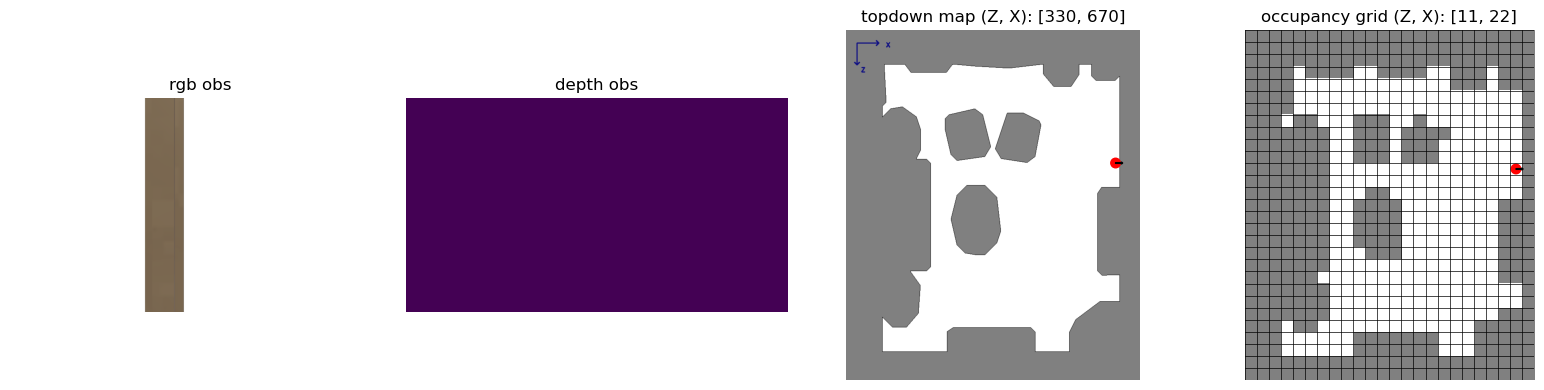

In [3]:
# Initialize an agent
agent = sim.initialize_agent(sim_settings["default_agent"])

# Sample a random position (within the possible ones)
grid_position = random.choice(grid_occ_positions)
idx = grid_occ_positions.index(grid_position)
wrld_position = real_wrld_positions[idx]
map_position = map_occ_positions[idx]

# Sample a random yaw rotation
agent_yaw = random.choice([0, 90, 180, 270])
agent_quart = myutils.yaw_to_quaternion(agent_yaw)
print("Agent yaw: ", agent_yaw)
print("Agent quaternion: ", agent_quart)

# Set agent state
agent_state = habitat_sim.AgentState()
agent_state.position = wrld_position
agent_state.rotation = agent_quart
agent.set_state(agent_state)

# Compute agent radius in both maps
min_bounds, max_bounds = sim.pathfinder.get_bounds()
x_dim = max_bounds[0] - min_bounds[0]
topdown_radius = (AGENT_RADIUS / x_dim * topdown_resolution[0])
occ_grid_radius = (AGENT_RADIUS / x_dim * occ_grid_resolution[0])

# Get initial agent position tuple and radius tuple
agent_radius_tpl = (topdown_radius, occ_grid_radius)
agent_positions_tpl = (map_position, grid_position)

# Get initial observations and maps
observations = sim.get_sensor_observations(0)
rgb = observations["color_sensor"]
depth = observations["depth_sensor"]

# Display the current simulation state (maps + observations)
simtools.display_sim_state(rgb, depth, topdown_map, occ_grid_map, agent_positions_tpl, agent_radius_tpl, agent_yaw)

In [4]:
# Define possible actions
actions = {
    "move_forward",
    "move_backward",
    "turn_left",
    "turn_right",
}

action turn_right
new_grid_position [11, 22]
new_agent_yaw 180
new_agent_quart quaternion(6.12323399573677e-17, 0, 1, 0)

0: 384x640 1 bench, 11.4ms
Speed: 15.9ms preprocess, 11.4ms inference, 659.9ms postprocess per image at shape (1, 3, 384, 640)


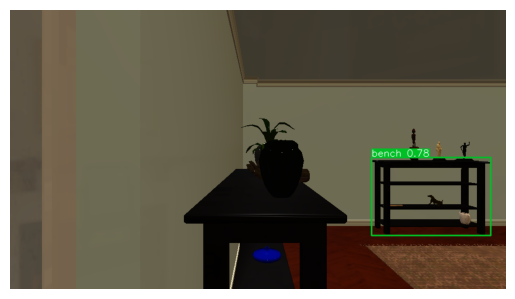

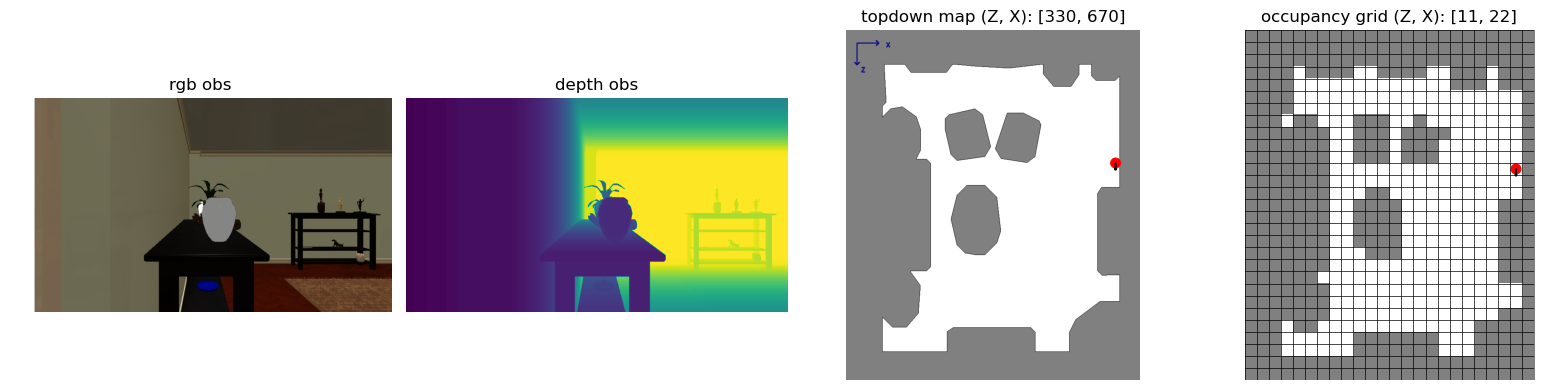

action turn_left
new_grid_position [11, 22]
new_agent_yaw 270
new_agent_quart quaternion(-0.707106781186547, 0, 0.707106781186548, 0)

0: 384x640 (no detections), 10.2ms
Speed: 5.7ms preprocess, 10.2ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)


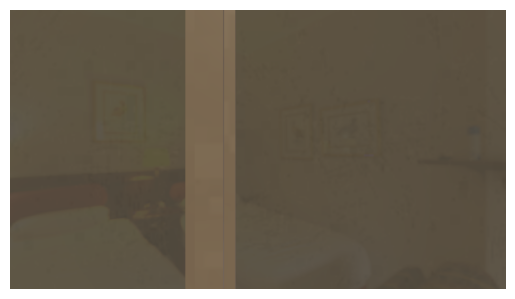

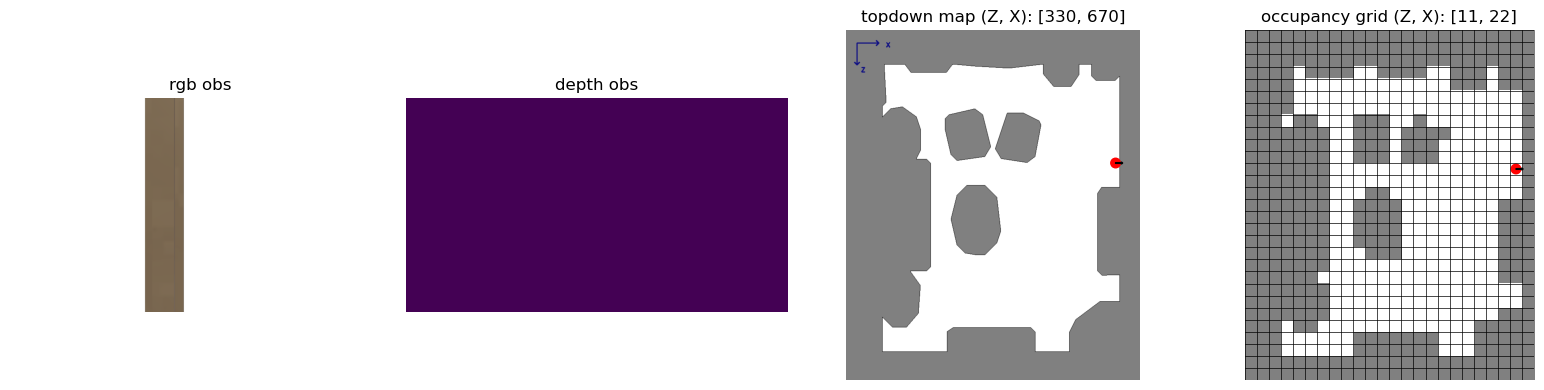

action move_backward
action move_backward
action turn_left
new_grid_position [11, 22]
new_agent_yaw 0
new_agent_quart quaternion(1, 0, 0, 0)

0: 384x640 (no detections), 10.2ms
Speed: 5.7ms preprocess, 10.2ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)


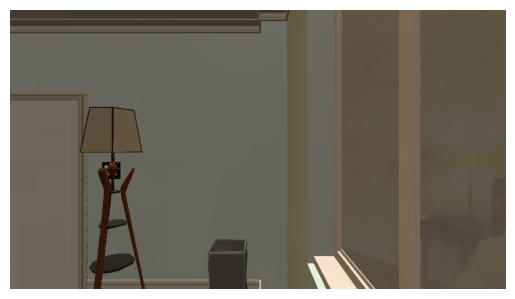

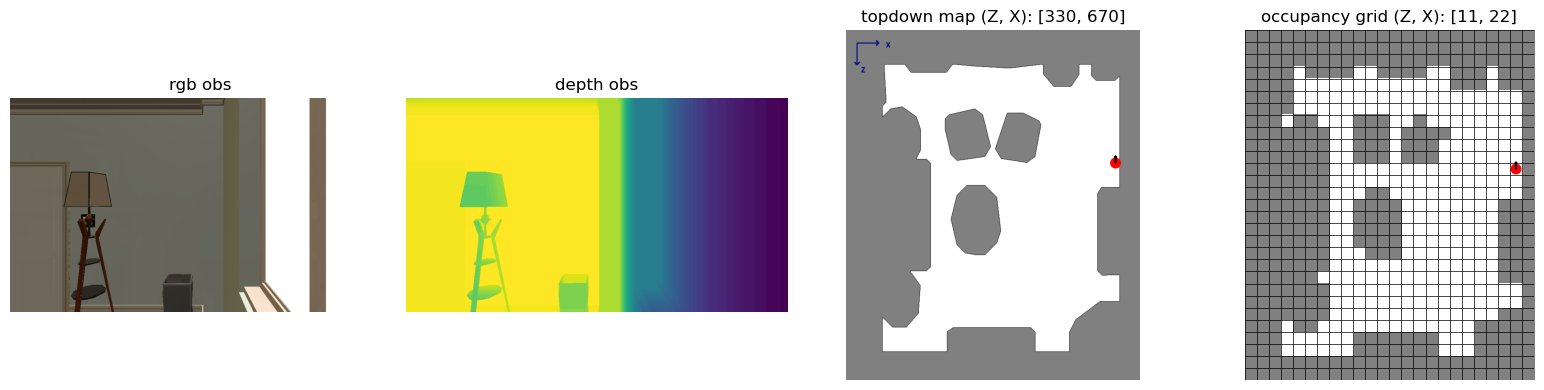

action move_forward
new_grid_position [10, 22]
new_agent_yaw 0
new_agent_quart quaternion(1, 0, 0, 0)

0: 384x640 (no detections), 9.9ms
Speed: 6.1ms preprocess, 9.9ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)


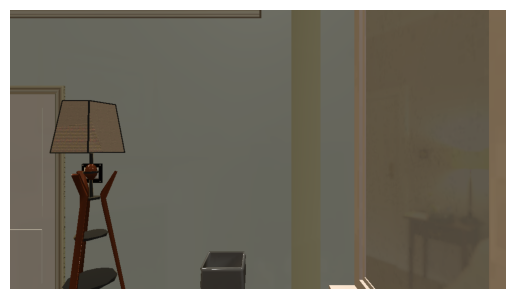

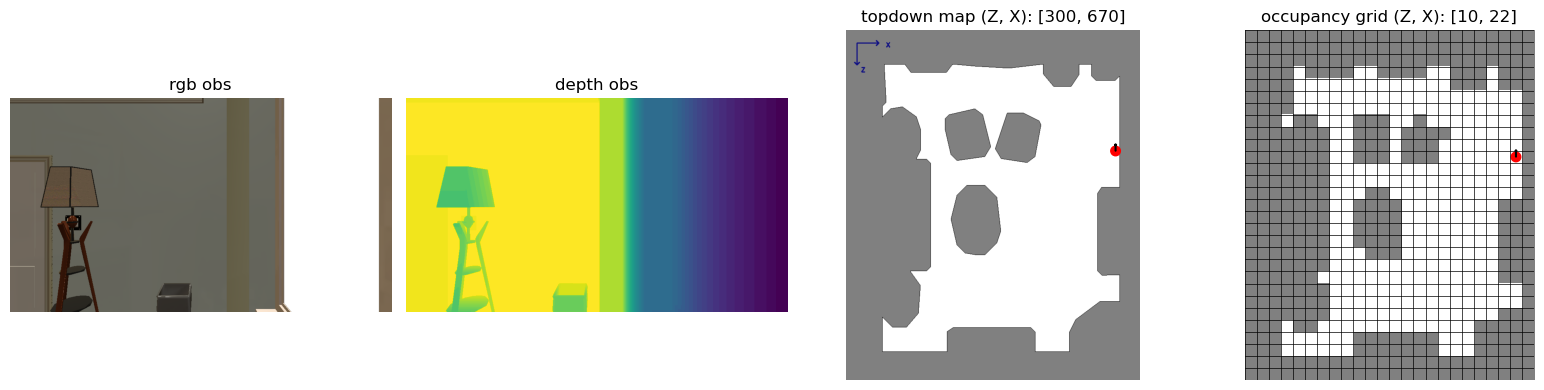

action turn_left
new_grid_position [10, 22]
new_agent_yaw 90
new_agent_quart quaternion(0.707106781186548, 0, 0.707106781186547, 0)

0: 384x640 2 chairs, 1 couch, 1 dining table, 10.0ms
Speed: 5.8ms preprocess, 10.0ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)


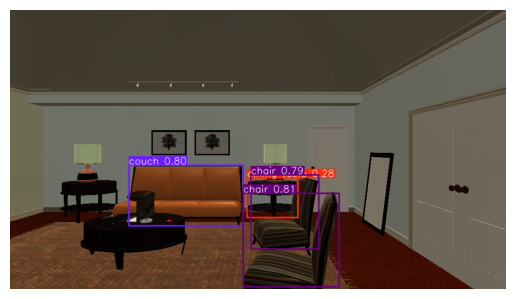

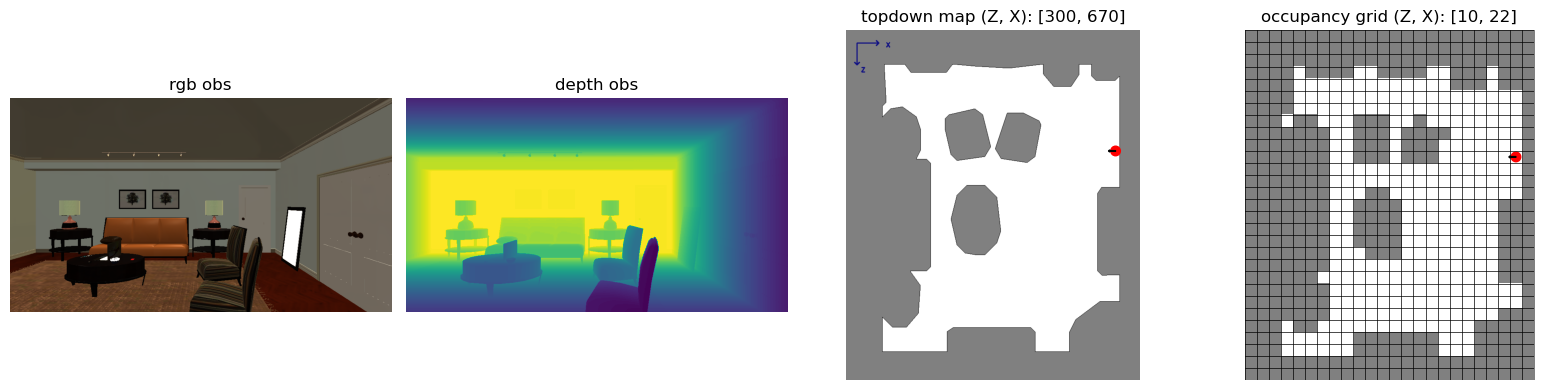

action move_backward
new_grid_position [10, 21]
new_agent_yaw 90
new_agent_quart quaternion(0.707106781186548, 0, 0.707106781186547, 0)

0: 384x640 2 chairs, 1 couch, 1 dining table, 10.3ms
Speed: 5.9ms preprocess, 10.3ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)


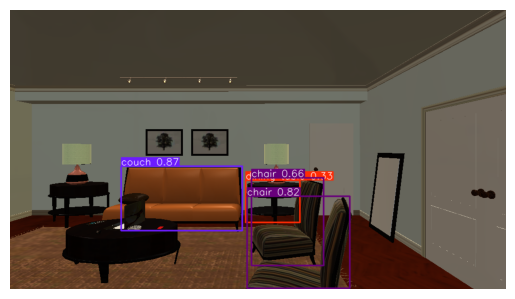

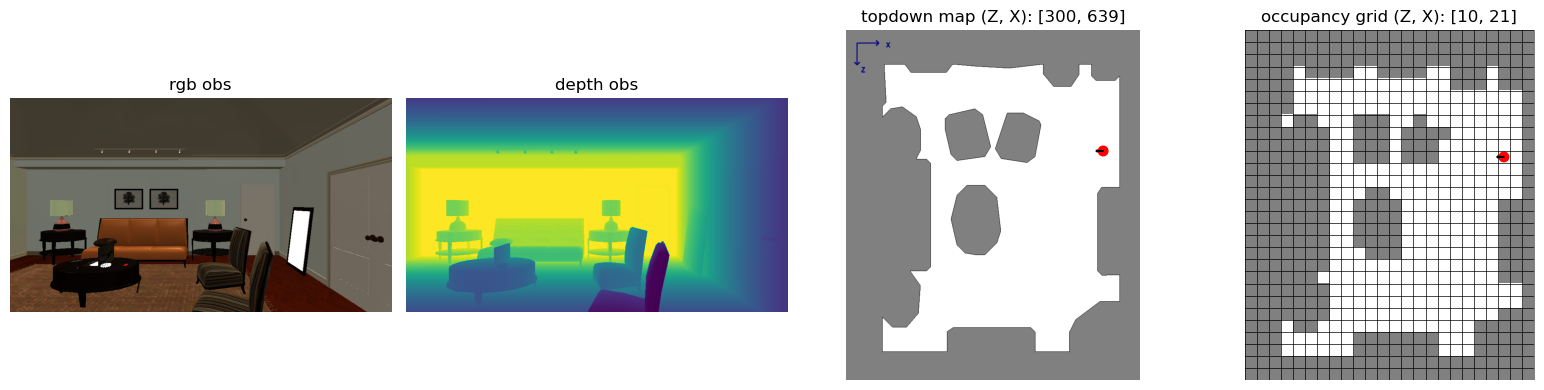

action turn_left
new_grid_position [10, 21]
new_agent_yaw 180
new_agent_quart quaternion(6.12323399573677e-17, 0, 1, 0)

0: 384x640 1 bench, 2 potted plants, 1 tv, 1 vase, 9.8ms
Speed: 6.1ms preprocess, 9.8ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)


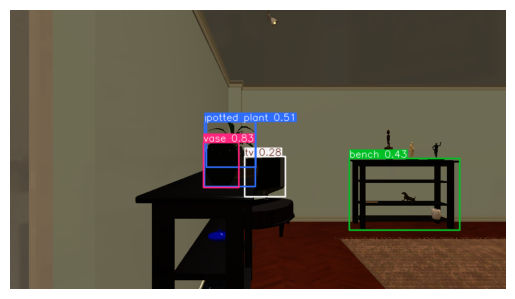

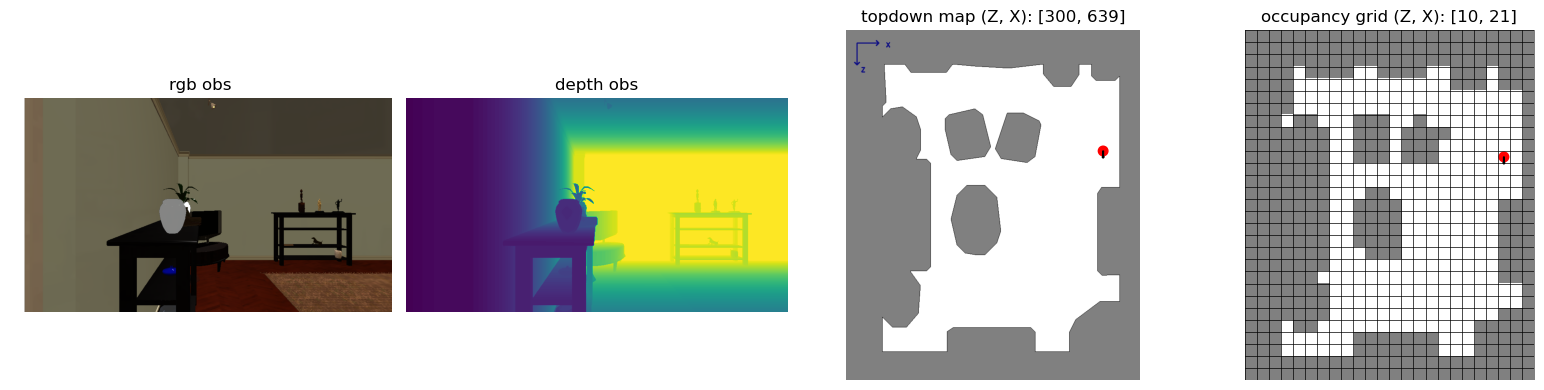

action move_forward
new_grid_position [11, 21]
new_agent_yaw 180
new_agent_quart quaternion(6.12323399573677e-17, 0, 1, 0)

0: 384x640 1 bench, 2 potted plants, 1 tv, 1 vase, 10.2ms
Speed: 6.0ms preprocess, 10.2ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)


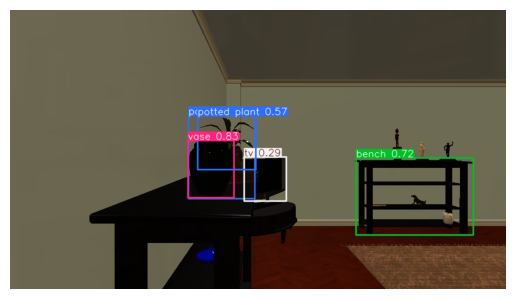

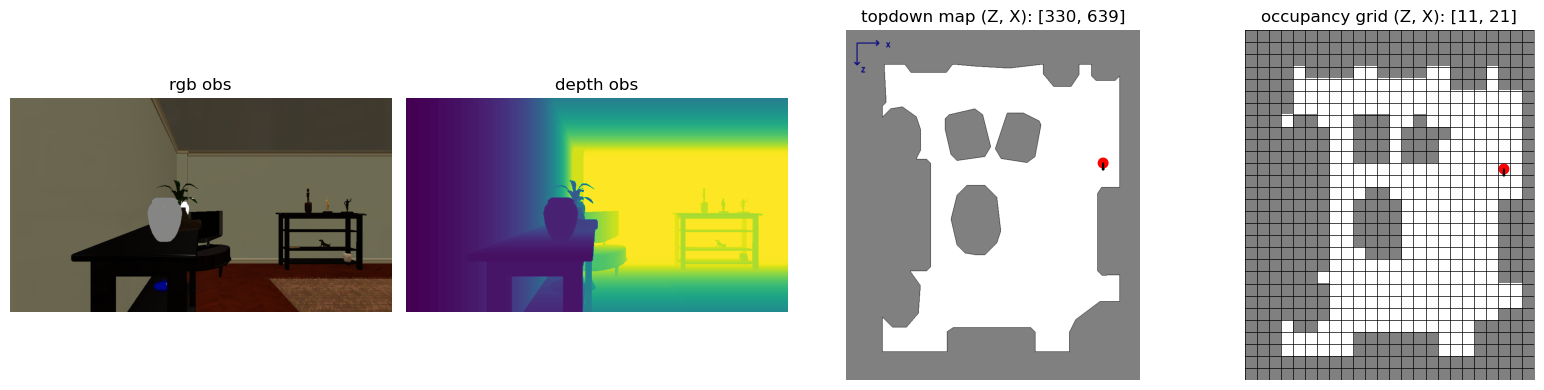

action move_forward
new_grid_position [12, 21]
new_agent_yaw 180
new_agent_quart quaternion(6.12323399573677e-17, 0, 1, 0)

0: 384x640 1 bench, 1 potted plant, 1 tv, 1 vase, 9.9ms
Speed: 6.0ms preprocess, 9.9ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)


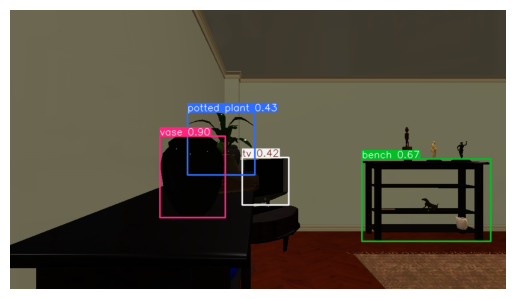

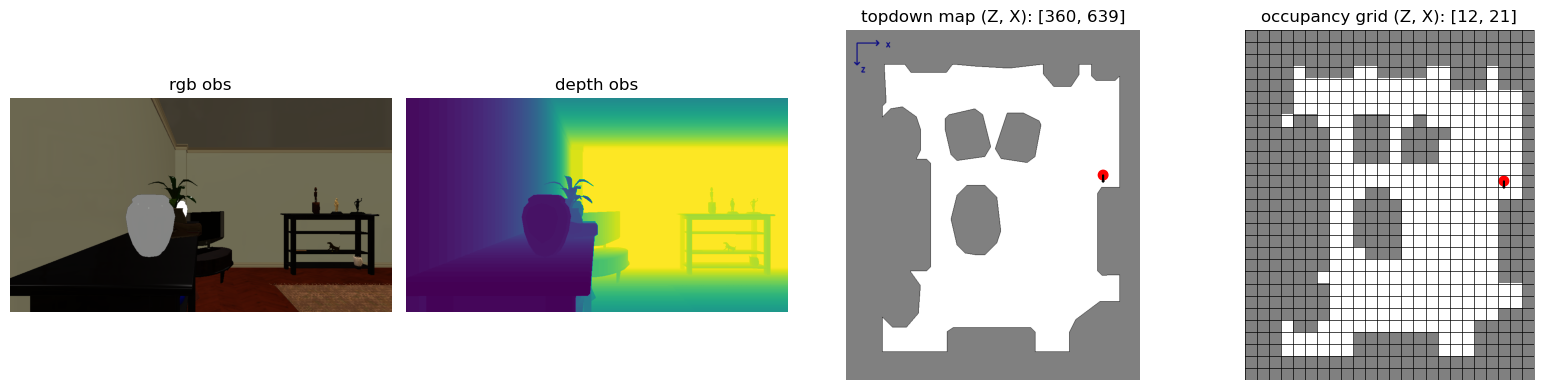

action move_backward
new_grid_position [11, 21]
new_agent_yaw 180
new_agent_quart quaternion(6.12323399573677e-17, 0, 1, 0)

0: 384x640 1 bench, 2 potted plants, 1 tv, 1 vase, 10.6ms
Speed: 5.7ms preprocess, 10.6ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)


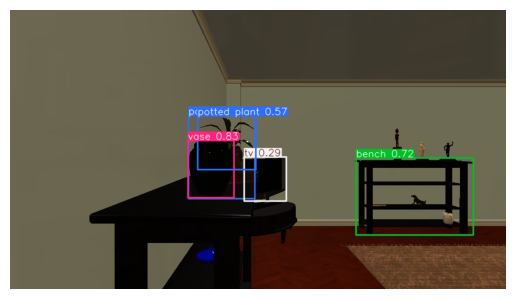

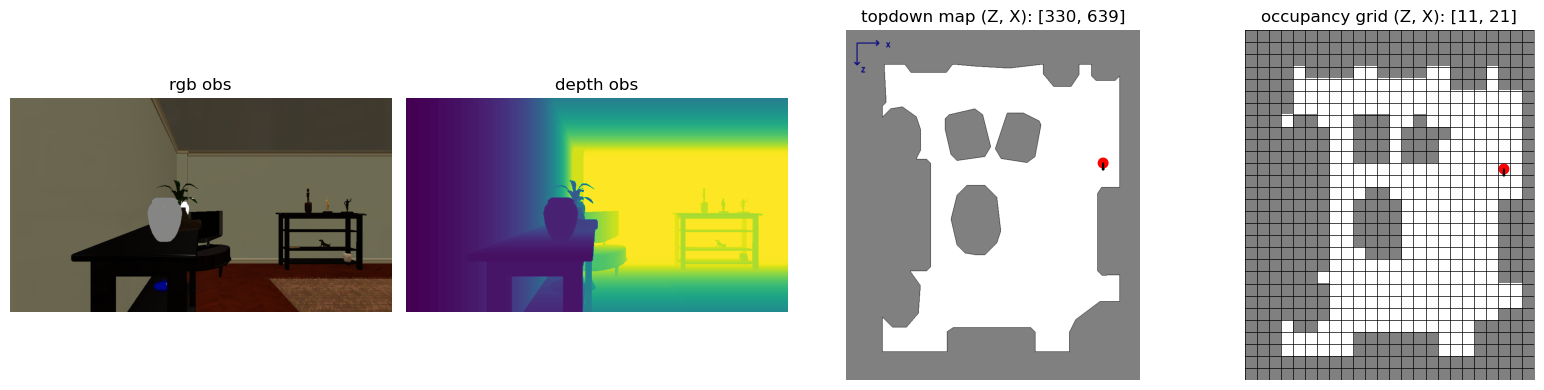

In [9]:
total_frames = 0
max_frames = 10

# Main simulation loop
while total_frames < max_frames:

    # Select an action randomly
    action = random.choice(list(actions))
    print("action", action)

    # Check if the action is valid
    if not simtools.is_action_valid(action, grid_position, agent_yaw, grid_occ_positions):
        continue

    # Perform the action
    new_grid_position, new_agent_yaw = simtools.perform_action(action, grid_position, agent_yaw)
    print("new_grid_position", new_grid_position)
    print("new_agent_yaw", new_agent_yaw)

    # Get new positions
    idx = grid_occ_positions.index(new_grid_position)
    new_map_position = map_occ_positions[idx]
    new_wrld_position = real_wrld_positions[idx]

    # Get quarternion from yaw
    new_agent_quart = myutils.yaw_to_quaternion(new_agent_yaw)
    print("new_agent_quart", new_agent_quart)
    
    # Set agent state
    agent_state.position = new_wrld_position
    agent_state.rotation = new_agent_quart
    agent.set_state(agent_state)

    # Get observations
    observations = sim.get_sensor_observations(0)
    rgb = observations["color_sensor"]
    depth = observations["depth_sensor"]

    # YOLO detections
    results = yolo_model.predict(rgb[:, :, :3])

    # Convert results to an image with bounding boxes
    img_with_boxes = results[0].plot()

    # Display the image
    plt.imshow(img_with_boxes)
    plt.axis("off")  # Hide axes for better visualization
    plt.show()

    # Display the current simulation state (maps + observations)
    simtools.display_sim_state(rgb, depth, topdown_map, occ_grid_map, (new_map_position, new_grid_position), agent_radius_tpl, new_agent_yaw)

    # Updates
    agent_yaw = new_agent_yaw
    grid_position = new_grid_position
    
    # Update step
    total_frames += 1